# Notebook 10: Hypothesis Testing

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Hypothesis Testing?

Hypothesis testing is a method to **decide, using sample data, whether a claim about a population is supported or not**. We start with an assumption, collect evidence from a sample, and check whether the evidence is strong enough to reject the assumption.

**Analogy:** A court case. The accused is *innocent until proven guilty* (the default assumption). The court rejects this only if the evidence is strong enough. If the evidence is weak, the verdict is "not enough evidence", which is not the same as "proven innocent".

**Why it matters in AI/ML:** A/B testing of a new feature, checking whether a new model is really better than the old one or just lucky, testing whether a feature has a real effect on the target, and detecting data drift all use hypothesis testing.

**Topics covered:** Null and Alternative Hypothesis, Significance Level, p-value, Confidence Interval, Type I and Type II Errors, One-tailed and Two-tailed Tests.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Null Hypothesis (H0) and Alternative Hypothesis (H1)

**Definition:**
- **Null hypothesis (H0):** the default assumption of "no effect" or "no difference". It always contains an equality (=, ≤ or ≥).
- **Alternative hypothesis (H1 or Ha):** the claim we try to find evidence for ("there is an effect or a difference").

We never "prove" H1 directly. We check whether the data gives enough evidence to **reject H0**.

**Steps of a hypothesis test:**
1. State H0 and H1
2. Choose the significance level (alpha, usually 0.05)
3. Collect the sample and calculate the test statistic
4. Find the p-value (or compare with the critical value)
5. Decision: if p-value < alpha, **reject H0**. Otherwise, **fail to reject H0**

**Numerical Example:** A food app claims the average delivery time is 30 minutes. We suspect it is different.
- H0: mu = 30 (the claim is true)
- H1: mu != 30 (the average is different)

**Business Example:** A company tests whether a new website design changes the average purchase value. H0: no change. H1: there is a change.

**AI/ML Example:** Comparing two models. H0: both models have the same accuracy. H1: the new model is better. In regression, H0 for each feature is "its coefficient is 0" (the feature has no effect).

**Important:** We say **"fail to reject H0"**, never "accept H0". Not finding evidence is not the same as proving there is no effect.

## 2. Significance Level (alpha)

**Definition:** Alpha is the maximum probability of a wrong rejection of H0 (a false alarm) that we are willing to accept. We choose it **before** looking at the data.

**Formula:**

$$\alpha = P(\text{reject } H_0 \mid H_0 \text{ is true})$$

| alpha | Confidence level | Used when |
|---|---|---|
| 0.10 | 90% | Exploratory work |
| 0.05 | 95% | Most business and ML work (default) |
| 0.01 | 99% | Medical or high-risk decisions |

**Numerical Example:** alpha = 0.05 means that if H0 is really true, we will wrongly reject it in about 5 out of 100 experiments.

**Business Example:** A drug company uses alpha = 0.01 because wrongly approving a useless drug is very costly.

**AI/ML Example:** In A/B tests, teams fix alpha = 0.05 before the test starts. Changing alpha after seeing the result is cheating (called p-hacking).

## 3. p-value

**Definition:** The p-value is the probability of getting a result **at least as extreme as the one we observed, assuming H0 is true**. A small p-value means the data is very unlikely under H0, so H0 looks doubtful.

**Decision rule:**
- p-value < alpha: **reject H0** (result is statistically significant)
- p-value >= alpha: **fail to reject H0**

**Formula (Z-test for a mean, sigma known):**

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Two-tailed p-value = 2 x P(Z > |z|)

**Numerical Example:** Claimed mean delivery time mu0 = 30 min, known sigma = 6, n = 36 orders, sample mean = 32.
SE = 6 / sqrt(36) = 1
Z = (32 - 30) / 1 = **2.0**
Two-tailed p-value = 2 x P(Z > 2) = 2 x 0.0228 = **0.0455**
Since 0.0455 < 0.05, we reject H0.

**Business Example:** An A/B test gives p = 0.03 for the new checkout page. If the new page had no real effect, we would see a difference this large only 3% of the time.

**AI/ML Example:** p-values of regression coefficients show which features have a statistically significant relationship with the target.

**Common mistakes:**
- p-value is **not** the probability that H0 is true.
- p = 0.04 does not mean "96% sure H1 is true".
- A tiny p-value does not mean the effect is large or important. With huge data, even a tiny, useless difference can have a tiny p-value.

In [2]:
mu0 = 30        # claimed mean
sigma = 6       # known standard deviation
n = 36
x_bar = 32      # sample mean

se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se

p_two = 2 * (1 - stats.norm.cdf(abs(z)))
p_right = 1 - stats.norm.cdf(z)

alpha = 0.05
print("Standard error :", se)
print("Z statistic    :", z)
print("Two-tailed p   :", round(p_two, 4))
print("Right-tailed p :", round(p_right, 4))
print("\nDecision at alpha = 0.05 (two-tailed):",
      "Reject H0" if p_two < alpha else "Fail to reject H0")

Standard error : 1.0
Z statistic    : 2.0
Two-tailed p   : 0.0455
Right-tailed p : 0.0228

Decision at alpha = 0.05 (two-tailed): Reject H0


**Explanation:** We calculate the standard error, convert the sample mean into a Z statistic, and find the tail probability using the normal CDF. The two-tailed p-value counts both tails, so it is double the one-tail value.

**Interpretation:** Z = 2 means the sample mean is 2 standard errors above the claimed mean. The two-tailed p-value is 0.0455, which is below 0.05, so we reject H0: there is evidence that the true average delivery time is not 30 minutes. Note that the result is only slightly below 0.05, so it is not overwhelming evidence.

## 4. Confidence Interval (CI)

**Definition:** A confidence interval is a range of values that is likely to contain the true population parameter. A 95% CI means: if we repeat the sampling many times and build an interval each time, about **95% of those intervals will contain the true value**.

**Formula (for a mean):**

$$CI = \bar{x} \pm z^* \cdot \frac{\sigma}{\sqrt{n}}$$

(Use t instead of z when sigma is unknown, especially for small samples.)

| Confidence | z* |
|---|---|
| 90% | 1.645 |
| 95% | 1.96 |
| 99% | 2.576 |

**Numerical Example:** x_bar = 32, SE = 1
95% CI = 32 +- 1.96 x 1 = **(30.04, 33.96)**
The interval does not contain 30, which matches our decision to reject H0: mu = 30 at alpha = 0.05.

**Business Example:** "Average order value is Rs. 520, with a 95% CI of Rs. 495 to Rs. 545." The range shows how precise the estimate is.

**AI/ML Example:** Reporting model accuracy with a confidence interval (for example 91% +- 2%) instead of one number, and checking whether two models' intervals overlap.

**Link with hypothesis testing:** A two-tailed test at alpha = 0.05 rejects H0 exactly when the hypothesized value lies outside the 95% CI.

In [4]:
# CI from the summary numbers
ci_low, ci_high = stats.norm.interval(0.95, loc=x_bar, scale=se)
print("95% CI:", (round(ci_low, 2), round(ci_high, 2)))
print("Is 30 inside the CI?", ci_low <= mu0 <= ci_high)

# What does "95% confidence" really mean? Repeat the experiment 2000 times
true_mean = 32
contains = 0
for _ in range(2000):
    sample = np.random.normal(true_mean, 6, 36)
    low, high = stats.t.interval(0.95, df=len(sample) - 1,
                                 loc=sample.mean(), scale=stats.sem(sample))
    if low <= true_mean <= high:
        contains += 1

print("\nIntervals that contained the true mean:", contains / 2000 * 100, "%")

95% CI: (np.float64(30.04), np.float64(33.96))
Is 30 inside the CI? False

Intervals that contained the true mean: 94.3 %


**Explanation:** First we build the CI from the summary numbers. Then we repeat sampling 2,000 times, build a 95% CI each time (using the t-distribution because sigma is estimated from the sample), and count how many intervals contain the true mean.

**Interpretation:** The CI (30.04, 33.96) does not include 30, so it agrees with the test. In the simulation, about 95% of the intervals contain the true mean. This is the real meaning of "95% confidence": it describes the **method**, not one particular interval.

## 5. One-tailed and Two-tailed Tests

**Definition:**
- **Two-tailed test:** checks for a difference in **either direction** (H1: mu != mu0). The rejection area is split into both tails.
- **One-tailed test:** checks for a difference in **one specific direction** (H1: mu > mu0 or H1: mu < mu0). The whole rejection area is in one tail.

| | Two-tailed | Right-tailed | Left-tailed |
|---|---|---|---|
| H1 | mu != mu0 | mu > mu0 | mu < mu0 |
| Critical Z (alpha = 0.05) | -1.96 and +1.96 | +1.645 | -1.645 |
| Use when | Any change matters | Only an increase matters | Only a decrease matters |

**Numerical Example:** Same data (Z = 2).
- Two-tailed p = 0.0455 (reject at 0.05)
- Right-tailed p = 0.0228 (reject at 0.05)

The one-tailed test has more power in its direction, but it cannot detect a change in the opposite direction.

**Business Example:**
- Two-tailed: "Did the new page change conversion?" (could be better or worse)
- Right-tailed: "Is the new battery life greater than 10 hours?"
- Left-tailed: "Has the defect rate gone below 2%?"

**AI/ML Example:** Testing whether a new model's accuracy is *higher* than the old model's (one-tailed). Testing whether a feature has *any* effect, positive or negative (two-tailed).

**Rule:** Decide one-tailed or two-tailed **before** seeing the data. Choosing one-tailed after the fact just to get a smaller p-value is not honest.

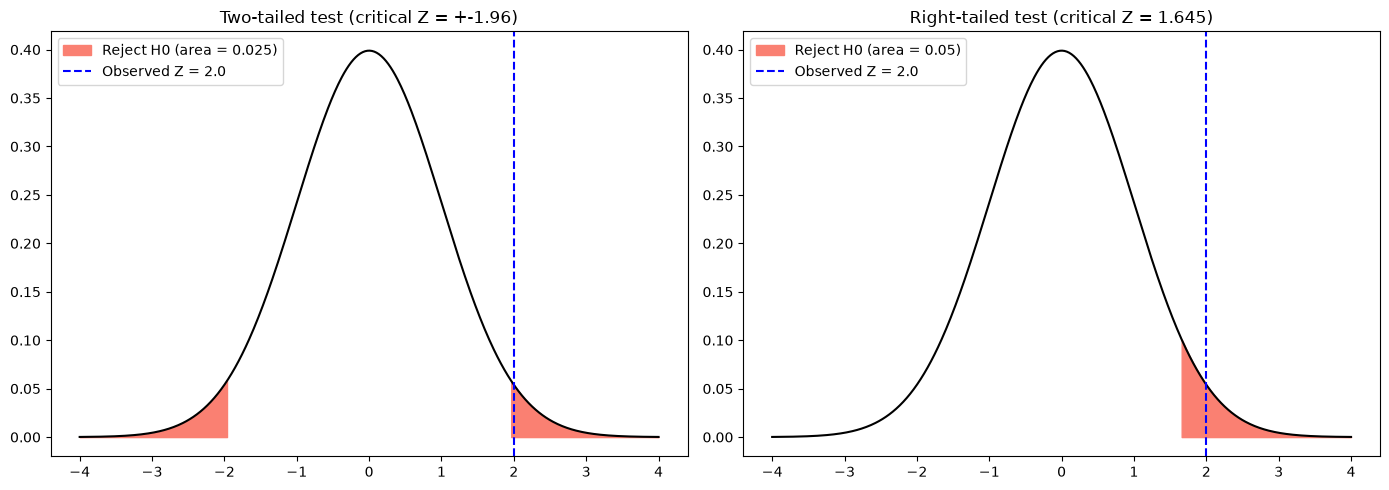

Two-tailed critical value  : 1.96
One-tailed critical value  : 1.645


In [5]:
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)
alpha = 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Two-tailed
crit2 = stats.norm.ppf(1 - alpha / 2)
axes[0].plot(x, y, "k")
axes[0].fill_between(x, y, where=(x <= -crit2), color="salmon", label=f"Reject H0 (area = {alpha/2})")
axes[0].fill_between(x, y, where=(x >= crit2), color="salmon")
axes[0].axvline(z, color="blue", linestyle="--", label=f"Observed Z = {z}")
axes[0].set_title(f"Two-tailed test (critical Z = +-{crit2:.2f})")
axes[0].legend()

# Right-tailed
crit1 = stats.norm.ppf(1 - alpha)
axes[1].plot(x, y, "k")
axes[1].fill_between(x, y, where=(x >= crit1), color="salmon", label=f"Reject H0 (area = {alpha})")
axes[1].axvline(z, color="blue", linestyle="--", label=f"Observed Z = {z}")
axes[1].set_title(f"Right-tailed test (critical Z = {crit1:.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Two-tailed critical value  :", round(crit2, 3))
print("One-tailed critical value  :", round(crit1, 3))

**Explanation:** The curve is the distribution of Z when H0 is true. The red areas are the **rejection regions** (together they have area alpha). The blue line is our observed Z.

**Interpretation:** The observed Z = 2 falls in the red zone in both charts, so we reject H0 in both. The two-tailed test splits alpha into two tails of 0.025 each, so its cut-off (1.96) is farther out than the one-tailed cut-off (1.645). That is why the one-tailed test rejects more easily, but only in one direction.

## 6. Type I and Type II Errors

**Definition:** Because we decide using a sample, we can make two kinds of mistakes.

| | H0 is actually TRUE | H0 is actually FALSE |
|---|---|---|
| **Reject H0** | **Type I error** (false positive), probability = alpha | Correct decision (power = 1 - beta) |
| **Fail to reject H0** | Correct decision | **Type II error** (false negative), probability = beta |

**Formulas:**

$$P(\text{Type I error}) = \alpha \qquad P(\text{Type II error}) = \beta \qquad \text{Power} = 1 - \beta$$

**Numerical Example:** H0: mu = 30, but the true mean is 32 (sigma = 6, n = 36, alpha = 0.05 two-tailed).
delta = (32 - 30) / 1 = 2
Power = P(Z > 1.96 - 2) + P(Z < -1.96 - 2) = about **0.516**
So beta = about **0.484**: nearly half the time we would miss this real difference.

**Easy memory trick:**
- Type I = "crying wolf" (alarm when there is no wolf)
- Type II = "missing the wolf" (no alarm when the wolf is there)

**Business Example:**
- Type I: launching a new feature because the test said it works, but it actually does nothing (wasted money).
- Type II: rejecting a new feature that actually works (lost opportunity).

**AI/ML Example:** In a medical or fraud model: a false positive is a Type I error (healthy person flagged as sick), a false negative is a Type II error (sick person missed). Depending on the cost, we adjust the decision threshold.

**Trade-off:** Reducing alpha (stricter test) increases beta. The only way to reduce both together is a **larger sample size**.

In [6]:
np.random.seed(42)
n, sigma, mu0 = 36, 6, 30
trials = 5000
alpha = 0.05

# --- Type I error: H0 is TRUE (real mean = 30) ---
samples_h0 = np.random.normal(mu0, sigma, size=(trials, n))
p_h0 = stats.ttest_1samp(samples_h0, mu0, axis=1).pvalue
type1_rate = np.mean(p_h0 < alpha)

# --- Type II error: H0 is FALSE (real mean = 32) ---
samples_h1 = np.random.normal(32, sigma, size=(trials, n))
p_h1 = stats.ttest_1samp(samples_h1, mu0, axis=1).pvalue
power = np.mean(p_h1 < alpha)

print("Simulated Type I error rate :", round(type1_rate, 3), "(expected about 0.05)")
print("Simulated power             :", round(power, 3))
print("Simulated Type II error     :", round(1 - power, 3))

# Theoretical power (Z-test)
delta = (32 - mu0) / (sigma / np.sqrt(n))
power_theory = (1 - stats.norm.cdf(1.96 - delta)) + stats.norm.cdf(-1.96 - delta)
print("\nTheoretical power (Z-test)  :", round(power_theory, 3))

# Effect of sample size on power
for size in [10, 36, 100, 200]:
    d = (32 - mu0) / (sigma / np.sqrt(size))
    pw = (1 - stats.norm.cdf(1.96 - d)) + stats.norm.cdf(-1.96 - d)
    print(f"n = {size:>3} -> power = {pw:.3f}")

Simulated Type I error rate : 0.053 (expected about 0.05)
Simulated power             : 0.487
Simulated Type II error     : 0.513

Theoretical power (Z-test)  : 0.516
n =  10 -> power = 0.184
n =  36 -> power = 0.516
n = 100 -> power = 0.915
n = 200 -> power = 0.997


**Explanation:** We run 5,000 experiments where H0 is true and count how often we wrongly reject it (Type I error rate). Then we run 5,000 experiments where the true mean is really 32 and count how often we correctly reject (power). Finally we calculate power for different sample sizes.

**Interpretation:** The Type I error rate comes out close to 0.05, which is exactly the alpha we chose. The power is about 0.5, so the Type II error is also about 0.5: with n = 36 we miss this real 2-minute difference about half the time. As the sample size grows, power rises close to 1. **A non-significant result from a small sample may only mean the test was too weak, not that there is no effect.**

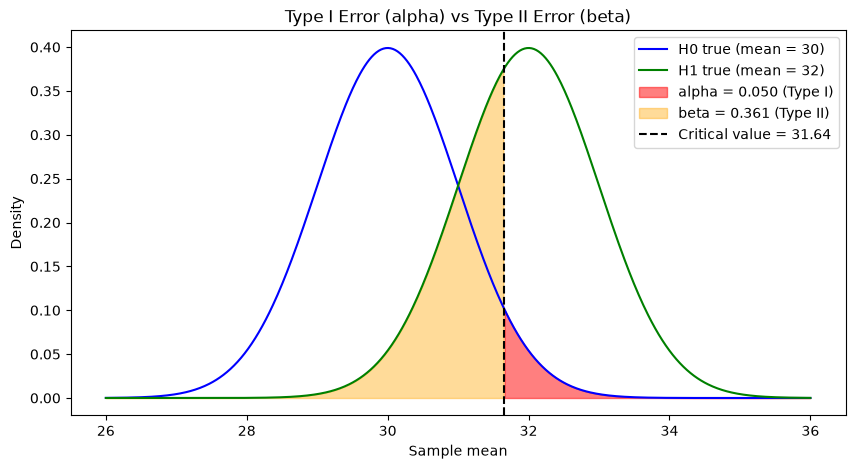

alpha = 0.05 | beta = 0.361 | power = 0.639


In [7]:
mu_null, mu_alt, se = 30, 32, 1
crit = mu_null + 1.645 * se          # one-tailed critical value on the mean scale

x = np.linspace(26, 36, 600)
null_curve = stats.norm.pdf(x, mu_null, se)
alt_curve = stats.norm.pdf(x, mu_alt, se)

alpha_area = 1 - stats.norm.cdf(crit, mu_null, se)
beta_area = stats.norm.cdf(crit, mu_alt, se)

plt.figure(figsize=(10, 5))
plt.plot(x, null_curve, "b", label="H0 true (mean = 30)")
plt.plot(x, alt_curve, "g", label="H1 true (mean = 32)")
plt.fill_between(x, null_curve, where=(x >= crit), color="red", alpha=0.5,
                 label=f"alpha = {alpha_area:.3f} (Type I)")
plt.fill_between(x, alt_curve, where=(x <= crit), color="orange", alpha=0.4,
                 label=f"beta = {beta_area:.3f} (Type II)")
plt.axvline(crit, color="black", linestyle="--", label=f"Critical value = {crit:.2f}")
plt.title("Type I Error (alpha) vs Type II Error (beta)")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.legend()
plt.show()

print("alpha =", round(alpha_area, 3), "| beta =", round(beta_area, 3), "| power =", round(1 - beta_area, 3))

**Explanation:** The blue curve is the sample mean's distribution when H0 is true, and the green curve is when H1 is true. The dashed line is the cut-off: we reject H0 when the sample mean is to its right. The red area is alpha (wrongly rejecting when blue is true), and the orange area is beta (failing to reject when green is true).

**Interpretation:** If we move the dashed line to the right (smaller alpha), the red area shrinks but the orange area grows, so the two errors trade off. If the two curves are farther apart (bigger effect) or narrower (bigger sample), the overlap becomes smaller and both errors drop.

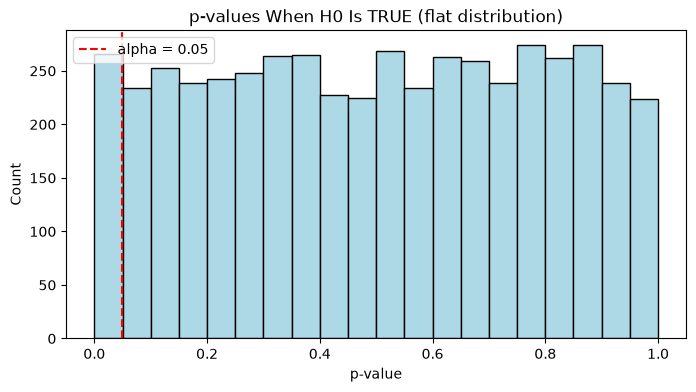

Fraction of p-values below 0.05 when H0 is true: 0.053


In [8]:
plt.figure(figsize=(8, 4))
plt.hist(p_h0, bins=20, color="lightblue", edgecolor="black")
plt.axvline(0.05, color="red", linestyle="--", label="alpha = 0.05")
plt.title("p-values When H0 Is TRUE (flat distribution)")
plt.xlabel("p-value")
plt.ylabel("Count")
plt.legend()
plt.show()

print("Fraction of p-values below 0.05 when H0 is true:", round(np.mean(p_h0 < 0.05), 3))

**Explanation:** We plot the p-values of the 5,000 experiments in which H0 was true.

**Interpretation:** The p-values are spread evenly between 0 and 1 (uniform). So even when there is no real effect, about 5% of tests give p < 0.05 just by chance. This is why running many tests and reporting only the "significant" ones (p-hacking) produces false discoveries. If you test 20 unrelated features, about one will look significant by luck.

## 7. Full Example: A/B Test (Conversion Rate)

**Scenario:** An e-commerce site tests a new checkout page.
- Old page (A): 5000 visitors, 400 purchases (8.0%)
- New page (B): 5000 visitors, 460 purchases (9.2%)

- H0: conversion rate of B = conversion rate of A
- H1: conversion rate of B != conversion rate of A (two-tailed)
- alpha = 0.05

**Formula (two-proportion Z-test):**

$$Z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_A} + \frac{1}{n_B}\right)}}, \quad \hat{p} = \frac{x_A + x_B}{n_A + n_B}$$

In [9]:
xA, nA = 400, 5000
xB, nB = 460, 5000

pA, pB = xA / nA, xB / nB
p_pool = (xA + xB) / (nA + nB)

se_ab = np.sqrt(p_pool * (1 - p_pool) * (1 / nA + 1 / nB))
z_ab = (pB - pA) / se_ab
p_ab = 2 * (1 - stats.norm.cdf(abs(z_ab)))

# 95% CI for the difference
se_diff = np.sqrt(pA * (1 - pA) / nA + pB * (1 - pB) / nB)
diff = pB - pA
ci = (diff - 1.96 * se_diff, diff + 1.96 * se_diff)

print(f"Conversion A: {pA:.3%} | Conversion B: {pB:.3%}")
print("Z statistic :", round(z_ab, 3))
print("p-value     :", round(p_ab, 4))
print("95% CI for difference:", (round(ci[0], 4), round(ci[1], 4)))
print("\nDecision:", "Reject H0" if p_ab < 0.05 else "Fail to reject H0")

Conversion A: 8.000% | Conversion B: 9.200%
Z statistic : 2.14
p-value     : 0.0323
95% CI for difference: (np.float64(0.001), np.float64(0.023))

Decision: Reject H0


**Explanation:** We pool the two groups to estimate the standard error under H0, calculate Z, and convert it into a p-value. We also build a confidence interval for the difference in conversion rates.

**Interpretation:** B converts at 9.2% versus 8.0% for A, a difference of 1.2 percentage points. The p-value is about 0.03, which is below 0.05, so we reject H0: the difference is statistically significant. The 95% CI for the difference is roughly 0.1 to 2.3 percentage points. It barely excludes 0, so the true improvement could be very small. Statistical significance is not the same as business importance: the team should also ask whether a gain of this size is worth the cost of the change.

## Summary

| Concept | Meaning | Key point |
|---|---|---|
| Null hypothesis (H0) | No effect or no difference | Default assumption, contains equality |
| Alternative hypothesis (H1) | There is an effect or difference | What we look for evidence of |
| Significance level (alpha) | Allowed false-alarm probability | Chosen before the test (usually 0.05) |
| p-value | Probability of a result this extreme if H0 is true | Reject H0 if p < alpha |
| Confidence interval | Range likely to contain the true value | 95% CI excludes mu0 means reject H0 |
| Type I error | Rejecting a true H0 | Probability = alpha |
| Type II error | Failing to reject a false H0 | Probability = beta |
| Power | Chance of detecting a real effect | 1 - beta, rises with sample size |
| One-tailed test | Effect in one direction | More power in that direction only |
| Two-tailed test | Effect in either direction | Safer default |

## Advantages
- Gives a systematic, objective way to make decisions from sample data
- Controls the false-alarm rate (alpha) in advance
- Works for A/B tests, model comparison, feature significance and quality control
- Confidence intervals show both the size and the uncertainty of an effect

## Limitations
- The p-value is often misunderstood, and it is not the probability that H0 is true
- Statistical significance does not mean practical importance, and large samples make tiny effects significant
- Small samples have low power, so real effects can be missed
- Running many tests increases false positives (p-hacking, multiple comparisons)
- Results depend on test assumptions (normality, independence, random sampling)
- The 0.05 threshold is a convention, not a law